# Практичне заняття: порівняння **MLP** vs **CNN** для розпізнавання зображень
### Виконав: Малютiн Максим
### Група: КС-31

## Мета
1. Побудувати та натренувати дві моделі для класифікації зображень:
   - **MLP (багатошаровий перцептрон)** — працює з *пласким* вектором ознак (Flatten).
   - **CNN (згорткова нейронна мережа)** — використовує згортки для витягування просторових ознак.
2. Порівняти моделі за:
   - точністю (**accuracy**) на тесті
   - кривими **loss/accuracy** (train vs val)
   - кількістю параметрів
   - (опційно) часом інференсу

## Датасет
Використаємо **Fashion-MNIST** (28×28, 10 класів).

---

## Структура роботи
1. Імпорт бібліотек, завантаження даних
2. Підготовка та візуалізація
3. Модель 1: MLP
4. Модель 2: CNN
5. Порівняння результатів + висновки
6. **TO DO** експерименти (для студентів)


In [2]:
# ===== 1) Імпорт бібліотек =====
import time
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# Відтворюваність (не гарантує 100% детермінізм на GPU)
np.random.seed(42)
keras.utils.set_random_seed(42)


## 2) Завантаження та підготовка даних
Fashion-MNIST:
- `x_train`: (60000, 28, 28)
- `x_test`: (10000, 28, 28)
- значення пікселів у діапазоні 0..255

Ми нормалізуємо дані до 0..1.


In [3]:
# ===== 2) Дані =====
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Нормалізація
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Для CNN додаємо канал: (H, W) -> (H, W, 1)
x_train_cnn = x_train[..., None]
x_test_cnn = x_test[..., None]

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)
print("x_train_cnn:", x_train_cnn.shape)


x_train: (60000, 28, 28) y_train: (60000,)
x_test : (10000, 28, 28) y_test : (10000,)
x_train_cnn: (60000, 28, 28, 1)


### Візуалізація прикладів


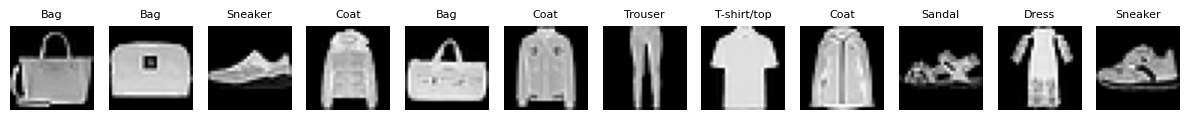

In [4]:
n = 12
idx = np.random.choice(len(x_train), size=n, replace=False)

plt.figure(figsize=(12, 3))
for i, j in enumerate(idx, start=1):
    plt.subplot(1, n, i)
    plt.imshow(x_train[j], cmap="gray")
    plt.title(class_names[y_train[j]], fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 3) Модель 1: **MLP (Flatten → Dense → Dense → Softmax)**

Ідея: зображення 28×28 перетворюємо у вектор 784 та навчаємо повнозв'язну мережу.

**Плюси:** проста, швидко реалізується.  
**Мінуси:** не враховує просторову структуру (сусідство пікселів).


In [5]:
def build_mlp(input_shape=(28, 28), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="MLP")
    return model

mlp = build_mlp()
mlp.summary()


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

EPOCHS = 8
BATCH = 128

history_mlp = mlp.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)


Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8162 - loss: 0.5231 - val_accuracy: 0.8538 - val_loss: 0.4078
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8636 - loss: 0.3774 - val_accuracy: 0.8672 - val_loss: 0.3721
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8775 - loss: 0.3348 - val_accuracy: 0.8713 - val_loss: 0.3583
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8869 - loss: 0.3081 - val_accuracy: 0.8722 - val_loss: 0.3575
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8939 - loss: 0.2879 - val_accuracy: 0.8778 - val_loss: 0.3428
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8995 - loss: 0.2710 - val_accuracy: 0.8765 - val_loss: 0.3505
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9048 - loss: 0.2563 - val_accuracy: 0.8783 - val_loss: 0.3517
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9087 - loss: 0.2440 - val_accuracy: 0.8803 - v

In [7]:
test_loss_mlp, test_acc_mlp = mlp.evaluate(x_test, y_test, verbose=0)
print(f"MLP test loss: {test_loss_mlp:.4f}")
print(f"MLP test acc : {test_acc_mlp:.4f}")


MLP test loss: 0.3805
MLP test acc : 0.8693


### Графіки навчання (MLP)


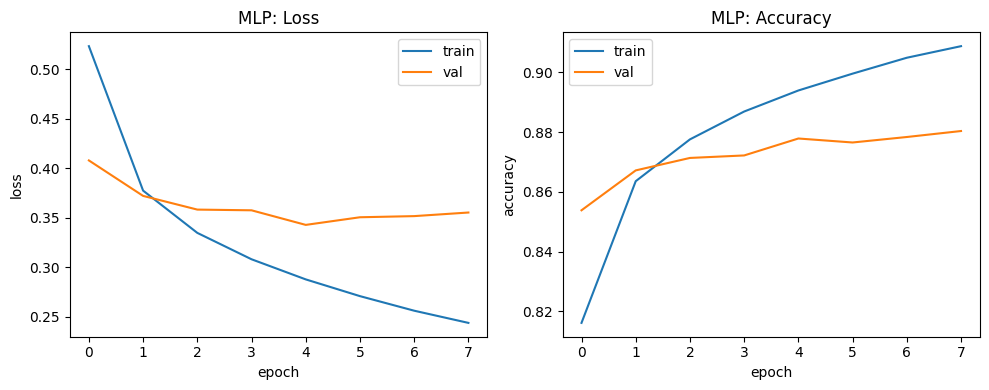

In [8]:
def plot_history(hist, title_prefix=""):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history["loss"], label="train")
    plt.plot(hist.history["val_loss"], label="val")
    plt.title(f"{title_prefix}Loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist.history["accuracy"], label="train")
    plt.plot(hist.history["val_accuracy"], label="val")
    plt.title(f"{title_prefix}Accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_mlp, "MLP: ")


## 4) Модель 2: **CNN (Conv → Pool → Conv → Pool → Dense → Softmax)**

CNN “бачить” локальні патерни через згортки, а pooling зменшує розмірність, зберігаючи важливі ознаки.


In [9]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="CNN")
    return model

cnn = build_cnn()
cnn.summary()


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = cnn.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)


Epoch 1/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8251 - loss: 0.4906 - val_accuracy: 0.8755 - val_loss: 0.3500
Epoch 2/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8870 - loss: 0.3164 - val_accuracy: 0.8968 - val_loss: 0.2921
Epoch 3/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9020 - loss: 0.2721 - val_accuracy: 0.9027 - val_loss: 0.2682
Epoch 4/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9110 - loss: 0.2437 - val_accuracy: 0.9083 - val_loss: 0.2490
Epoch 5/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9189 - loss: 0.2210 - val_accuracy: 0.9128 - val_loss: 0.2404
Epoch 6/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9260 - loss: 0.2004 - val_accuracy: 0.9150 - val_loss: 0.2334
Epoch 7/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9330 - loss: 0.1823 - val_accuracy: 0.9172 - val_loss: 0.2321
Epoch 8/8
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9401 - loss: 0.1650 - val_accuracy: 0.9182 - v

In [11]:
test_loss_cnn, test_acc_cnn = cnn.evaluate(x_test_cnn, y_test, verbose=0)
print(f"CNN test loss: {test_loss_cnn:.4f}")
print(f"CNN test acc : {test_acc_cnn:.4f}")


CNN test loss: 0.2575
CNN test acc : 0.9120


### Графіки навчання (CNN)


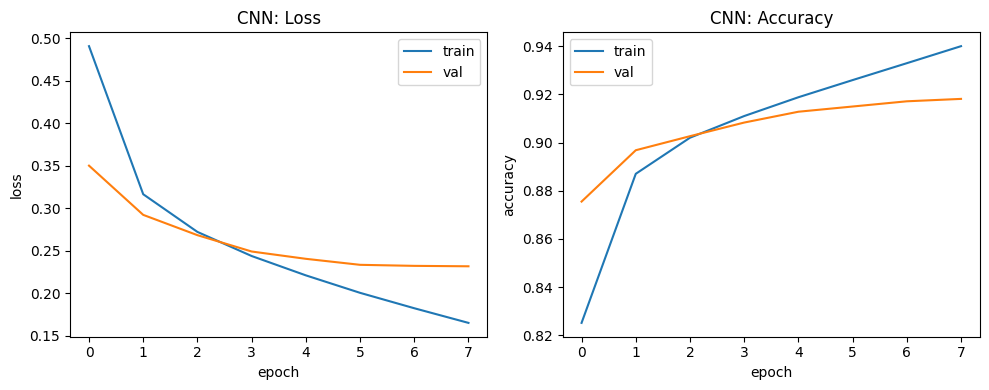

In [12]:
plot_history(history_cnn, "CNN: ")


## 5) Порівняння моделей

Порівняємо:
- accuracy на тесті
- кількість параметрів
- (опційно) швидкість інференсу на невеликому батчі


In [13]:
def count_params(model):
    return int(np.sum([np.prod(w.shape) for w in model.get_weights()]))

params_mlp = count_params(mlp)
params_cnn = count_params(cnn)

print("MLP params:", params_mlp)
print("CNN params:", params_cnn)
print("MLP test acc:", float(test_acc_mlp))
print("CNN test acc:", float(test_acc_cnn))


MLP params: 235146
CNN params: 421642
MLP test acc: 0.8693000078201294
CNN test acc: 0.9120000004768372


In [14]:
# Опційно: приблизний час інференсу (залежить від CPU/GPU)
def inference_time_ms(model, x, n_runs=30):
    _ = model.predict(x, verbose=0)  # warmup
    t0 = time.time()
    for _ in range(n_runs):
        _ = model.predict(x, verbose=0)
    t1 = time.time()
    return (t1 - t0) * 1000 / n_runs

batch = 256
x_batch_mlp = x_test[:batch]
x_batch_cnn = x_test_cnn[:batch]

ms_mlp = inference_time_ms(mlp, x_batch_mlp, n_runs=20)
ms_cnn = inference_time_ms(cnn, x_batch_cnn, n_runs=20)

print(f"Inference time per run (batch={batch}):")
print(f"  MLP: {ms_mlp:.2f} ms")
print(f"  CNN: {ms_cnn:.2f} ms")


Inference time per run (batch=256):
  MLP: 45.39 ms
  CNN: 48.99 ms


## 6) Якість по класах: confusion matrix та звіт


MLP
              precision    recall  f1-score   support

 T-shirt/top     0.7992    0.8400    0.8191      1000
     Trouser     0.9990    0.9610    0.9796      1000
    Pullover     0.8459    0.7080    0.7708      1000
       Dress     0.8031    0.9300    0.8619      1000
        Coat     0.7476    0.8530    0.7968      1000
      Sandal     0.9330    0.9750    0.9535      1000
       Shirt     0.7323    0.6320    0.6785      1000
     Sneaker     0.8942    0.9550    0.9236      1000
         Bag     0.9756    0.9610    0.9683      1000
  Ankle boot     0.9865    0.8780    0.9291      1000

    accuracy                         0.8693     10000
   macro avg     0.8716    0.8693    0.8681     10000
weighted avg     0.8716    0.8693    0.8681     10000



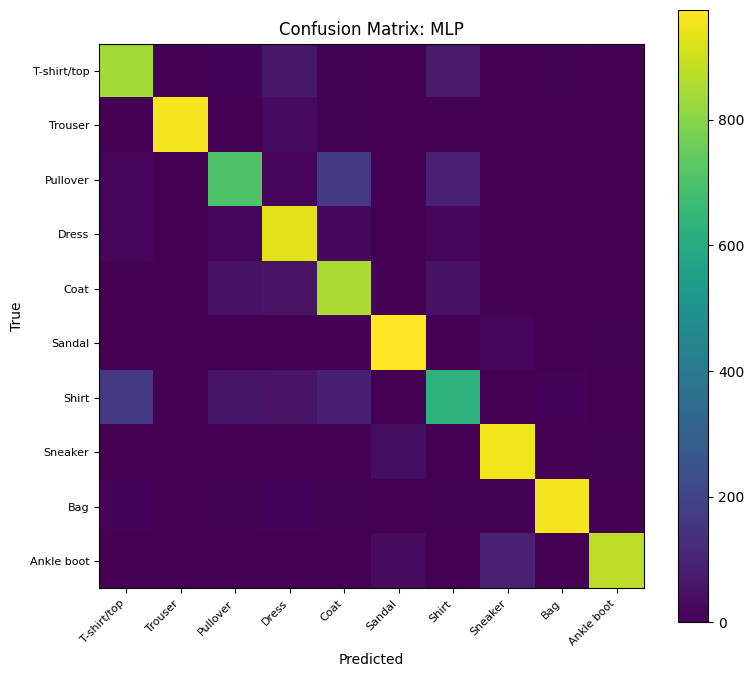

In [15]:
def eval_report(model, x, y, title=""):
    y_prob = model.predict(x, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    cm = confusion_matrix(y, y_pred)
    print(title)
    print(classification_report(y, y_pred, target_names=class_names, digits=4))

    plt.figure(figsize=(8, 7))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix: {title}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.xticks(range(10), class_names, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(10), class_names, fontsize=8)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

eval_report(mlp, x_test, y_test, title="MLP")


CNN
              precision    recall  f1-score   support

 T-shirt/top     0.8673    0.8690    0.8681      1000
     Trouser     0.9949    0.9770    0.9859      1000
    Pullover     0.8371    0.8890    0.8623      1000
       Dress     0.9103    0.9130    0.9116      1000
        Coat     0.8539    0.8650    0.8594      1000
      Sandal     0.9529    0.9920    0.9721      1000
       Shirt     0.7855    0.7250    0.7540      1000
     Sneaker     0.9597    0.9520    0.9558      1000
         Bag     0.9752    0.9830    0.9791      1000
  Ankle boot     0.9805    0.9550    0.9676      1000

    accuracy                         0.9120     10000
   macro avg     0.9117    0.9120    0.9116     10000
weighted avg     0.9117    0.9120    0.9116     10000



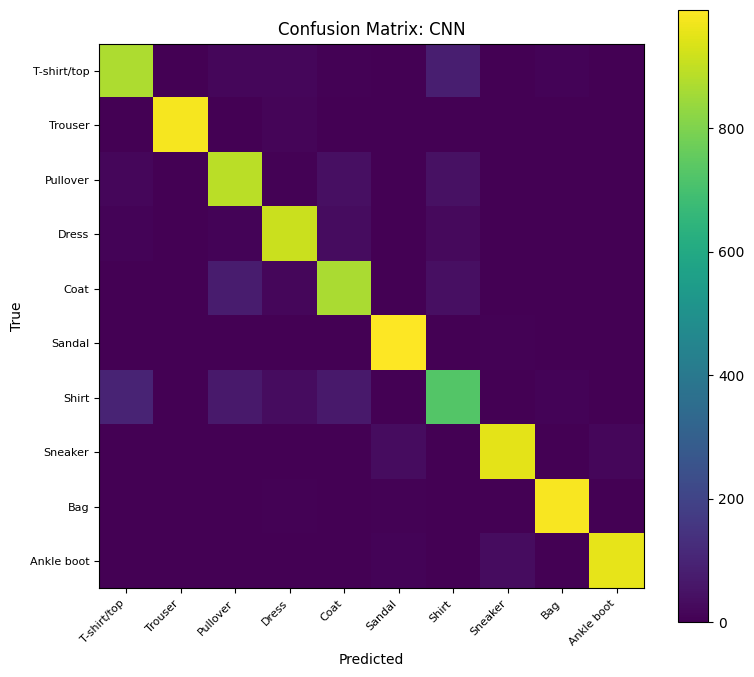

In [16]:
eval_report(cnn, x_test_cnn, y_test, title="CNN")


## 7) Висновки (шаблон)

**Заповніть коротко:**
- Яка модель показала кращу точність і чому?
- Як відрізняється кількість параметрів?
- Які класи плутаються найчастіше? Чому саме вони?


# ✅ TO DO

1. **Змінити MLP**:
   - (а) змініть кількість нейронів (наприклад 128/512)
   - (б) додайте `Dropout(0.2–0.5)`
   - (в) оцініть overfitting по train/val кривих


Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7972 - loss: 0.5658 - val_accuracy: 0.8513 - val_loss: 0.4077
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8509 - loss: 0.4079 - val_accuracy: 0.8638 - val_loss: 0.3694
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8641 - loss: 0.3725 - val_accuracy: 0.8667 - val_loss: 0.3634
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8718 - loss: 0.3502 - val_accuracy: 0.8793 - val_loss: 0.3299
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8794 - loss: 0.3337 - val_accuracy: 0.8768 - val_loss: 0.3425
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8808 - loss: 0.3209 - val_accuracy: 0.8812 - val_loss: 0.3258
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8853 - loss: 0.3091 - val_accuracy: 0.8808 - val_loss: 0.3314
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8886 - loss: 0.2983 - val_accuracy: 0.

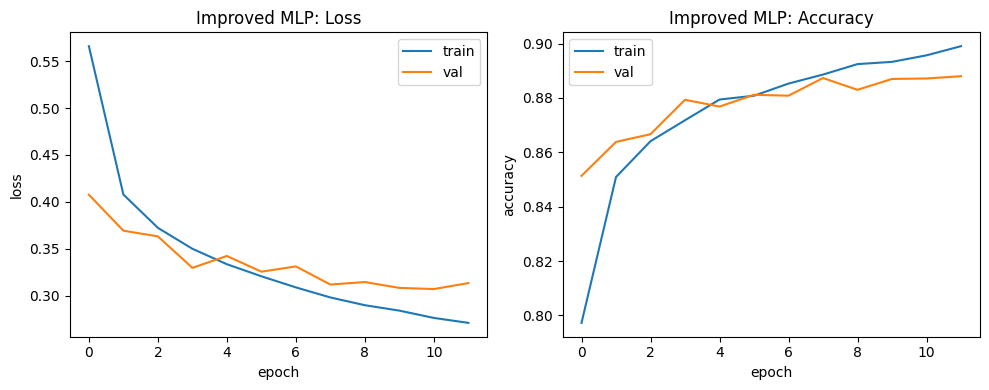

Improved MLP test acc: 0.8829


In [17]:
def build_mlp_improved(input_shape=(28, 28), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        # (а) Збільшуємо кількість нейронів
        layers.Dense(512, activation="relu"),
        # (б) Додаємо Dropout для боротьби з перенавчанням
        layers.Dropout(0.3), 
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation="softmax")
    ], name="Improved_MLP")
    return model

mlp_v2 = build_mlp_improved()
mlp_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

# Тренування
history_mlp_v2 = mlp_v2.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=12, # Трохи більше епох, щоб побачити ефект Dropout
    batch_size=128,
    verbose=1)

# Візуалізація результатів
plot_history(history_mlp_v2, "Improved MLP: ")

test_loss_v2, test_acc_v2 = mlp_v2.evaluate(x_test, y_test, verbose=0)
print(f"Improved MLP test acc: {test_acc_v2:.4f}")

2. **Змінити CNN**:
   - (а) додайте ще один `Conv2D` блок
   - (б) додайте `BatchNormalization`
   - (в) додайте `Dropout` перед Dense

Model: "CNN_v2_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8239 - loss: 0.4964 - val_accuracy: 0.6563 - val_loss: 1.3022
Epoch 2/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8845 - loss: 0.3188 - val_accuracy: 0.8970 - val_loss: 0.2758
Epoch 3/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9009 - loss: 0.2689 - val_accuracy: 0.9110 - val_loss: 0.2532
Epoch 4/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9111 - loss: 0.2396 - val_accuracy: 0.9072 - val_loss: 0.2665
Epoch 5/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9202 - loss: 0.2147 - val_accuracy: 0.9132 - val_loss: 0.2456
Epoch 6/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9280 - loss: 0.1927 - val_accuracy: 0.9153 - val_loss: 0.2331
Epoch 7/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9345 - loss: 0.1753 - val_accuracy: 0.9217 - val_loss: 0.2269
Epoch 8/12
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9394 - loss: 0.1608 - va

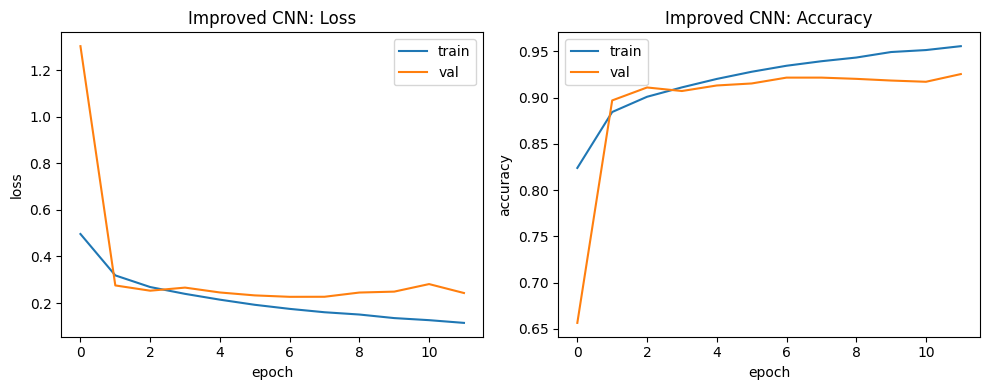

In [18]:
def build_cnn_v2(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Блок 1
        layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(), # (б) Додаємо нормалізацію
        layers.MaxPooling2D(pool_size=2),
        
        # Блок 2 (а) Додаємо ще один Conv2D блок
        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        
        # Блок 3
        layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        
        layers.Flatten(),
        
        # Повнозв'язний шар
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5), # (в) Додаємо Dropout перед Dense (Softmax)
        
        layers.Dense(num_classes, activation="softmax")
    ], name="CNN_v2_Improved")
    return model

cnn_v2 = build_cnn_v2()
cnn_v2.summary()

# Компіляція
cnn_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

# Тренування
history_cnn_v2 = cnn_v2.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=12,
    batch_size=128,
    verbose=1)

# оцінка результатів
test_loss_v2, test_acc_v2 = cnn_v2.evaluate(x_test_cnn, y_test, verbose=0)
print(f"Improved CNN test acc : {test_acc_v2:.4f}")

# візуалізація
plot_history(history_cnn_v2, "Improved CNN: ")

3. **Оптимізатор**:
   - порівняйте `Adam` vs `SGD(momentum=0.9)` (однакова кількість епох)

Тренування з оптимізатором Adam
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.8251 - loss: 0.4999 - val_accuracy: 0.7017 - val_loss: 0.8888
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8865 - loss: 0.3187 - val_accuracy: 0.9067 - val_loss: 0.2546
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9028 - loss: 0.2681 - val_accuracy: 0.9088 - val_loss: 0.2539
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9141 - loss: 0.2362 - val_accuracy: 0.8877 - val_loss: 0.3127
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9234 - loss: 0.2084 - val_accuracy: 0.9202 - val_loss: 0.2247
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.9313 - loss: 0.1904 - val_accuracy: 0.9075 - val_loss: 0.2545
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9331 - loss: 0.1786 - val_accuracy: 0.8977 - val_loss: 0.3097
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - acc

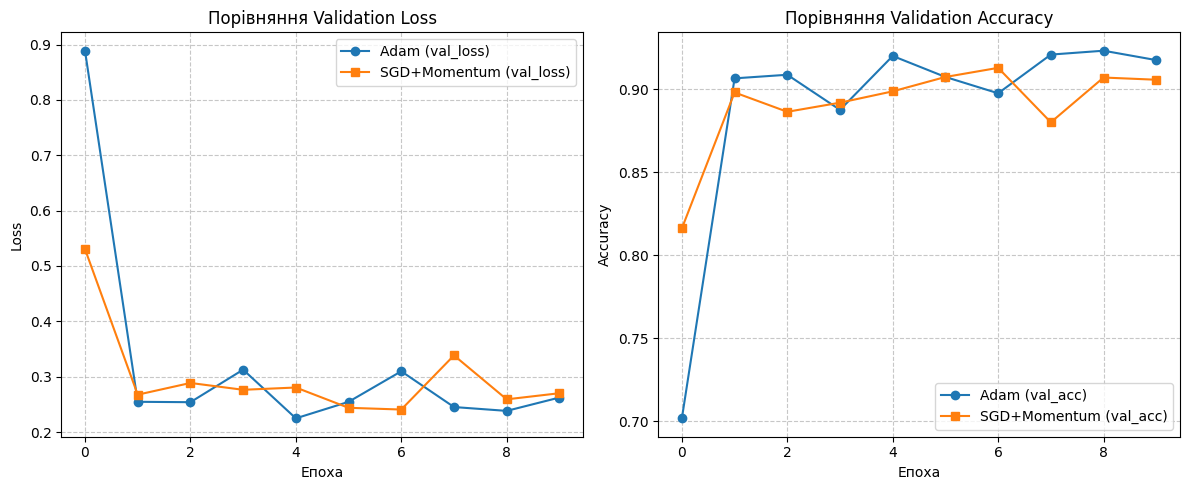


Фінальна точність на тесті (Adam): 0.9120
Фінальна точність на тесті (SGD+Momentum): 0.9020


In [19]:
# Задаємо однакові умови
EPOCHS_OPT = 10
BATCH_OPT = 128

# 1. Експеримент з Adam
print("Тренування з оптимізатором Adam") 
model_adam = build_cnn_v2() # cтворюємо нову модель з випадковими вагами
model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_adam = model_adam.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS_OPT,
    batch_size=BATCH_OPT,
    verbose=1
)

# 2. Експеримент з SGD + Momentum
print("\nТренування з оптимізатором SGD (momentum=0.9)")
model_sgd = build_cnn_v2() # Створюємо ще одну нову модель
model_sgd.compile(
    # Для SGD часто потрібен трохи більший learning_rate, наприклад 0.01
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_sgd = model_sgd.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS_OPT,
    batch_size=BATCH_OPT,
    verbose=1
)

# 3. Візуалізація порівняння
plt.figure(figsize=(12, 5))

# Порівняння Loss на валідації
plt.subplot(1, 2, 1)
plt.plot(history_adam.history["val_loss"], label="Adam (val_loss)", marker="o")
plt.plot(history_sgd.history["val_loss"], label="SGD+Momentum (val_loss)", marker="s")
plt.title("Порівняння Validation Loss")
plt.xlabel("Епоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Порівняння Accuracy на валідації
plt.subplot(1, 2, 2)
plt.plot(history_adam.history["val_accuracy"], label="Adam (val_acc)", marker="o")
plt.plot(history_sgd.history["val_accuracy"], label="SGD+Momentum (val_acc)", marker="s")
plt.title("Порівняння Validation Accuracy")
plt.xlabel("Епоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Фінальна оцінка на тестовому наборі
_, acc_adam = model_adam.evaluate(x_test_cnn, y_test, verbose=0)
_, acc_sgd = model_sgd.evaluate(x_test_cnn, y_test, verbose=0)

print(f"\nФінальна точність на тесті (Adam): {acc_adam:.4f}")
print(f"Фінальна точність на тесті (SGD+Momentum): {acc_sgd:.4f}")

4. **Аугментація** (для CNN):
   - `RandomFlip` / `RandomRotation` / `RandomZoom`
   - перевірте, чи зросла точність на тесті

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7711 - loss: 0.6441 - val_accuracy: 0.7667 - val_loss: 0.6455
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8424 - loss: 0.4357 - val_accuracy: 0.8670 - val_loss: 0.3450
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8572 - loss: 0.3925 - val_accuracy: 0.8690 - val_loss: 0.3507
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.8664 - loss: 0.3668 - val_accuracy: 0.8817 - val_loss: 0.3228
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8756 - loss: 0.3426 - val_accuracy: 0.8842 - val_loss: 0.3051
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8800 - loss: 0.3236 - val_accuracy: 0.8767 - val_loss: 0.3352
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8872 - loss: 0.3117 - val_accuracy: 0.8900 - val_loss: 0.2889
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8906 - loss: 0.2994 - 

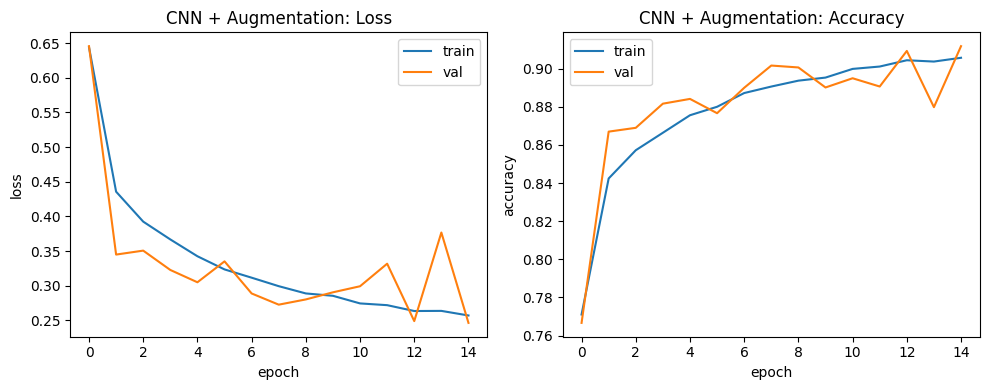

In [20]:
# 4. Експеримент з Аугментацією даних

# Створюємо окремий блок аугментації
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),            # Випадкове віддзеркалення по горизонталі
    layers.RandomRotation(0.05),                # Випадковий поворот на +- 5% (близько 18 градусів)
    layers.RandomZoom(height_factor=(-0.1, 0.1)) # Випадковий зум (збільшення/зменшення до 10%)
], name="Data_Augmentation")

def build_cnn_augmented(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # Вбудовуємо аугментацію першим кроком
        # Вона буде працювати тiльки під час model.fit() і вимикатиметься під час evaluate/predict
        data_augmentation, 
        
        # Блок 1
        layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        
        # Блок 2
        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        
        # Блок 3
        layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=2),
        
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ], name="CNN_Augmented")
    return model

# створюємо, компілюємо та тренуємо модель
cnn_aug = build_cnn_augmented()

cnn_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# трохи більше епох для збіжності
EPOCHS_AUG = 15 

history_aug = cnn_aug.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS_AUG,
    batch_size=128,
    verbose=1
)

# Оцінка
test_loss_aug, test_acc_aug = cnn_aug.evaluate(x_test_cnn, y_test, verbose=0)
print(f"\nCNN з Аугментацією test acc : {test_acc_aug:.4f}")

# Візуалізація
plot_history(history_aug, "CNN + Augmentation: ")

5. **Batch size**:
   - спробуйте `batch_size=32` та `batch_size=256`
   - як змінюється швидкість/якість?

In [ ]:
import time

EPOCHS_BATCH = 8 # Візьмемо 8 епох для чіткої картини

# 1. batch_size = 32
print("Тренування з batch_size = 32")
cnn_b32 = build_cnn() # використовуємо базову CNN
cnn_b32.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

start_time_32 = time.time()
history_b32 = cnn_b32.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS_BATCH,
    batch_size=32,      # малий батч
    verbose=1
)
time_b32 = time.time() - start_time_32

# 2. batch_size = 256
print("\nТренування з batch_size = 256")
cnn_b256 = build_cnn()
cnn_b256.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

start_time_256 = time.time()
history_b256 = cnn_b256.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=EPOCHS_BATCH,
    batch_size=256,     # Великий батч
    verbose=1
)
time_b256 = time.time() - start_time_256

# 3. Порівняння результатів
_, acc_b32 = cnn_b32.evaluate(x_test_cnn, y_test, verbose=0)
_, acc_b256 = cnn_b256.evaluate(x_test_cnn, y_test, verbose=0)

print("\n" + "="*40)
print("Результати порiвняння batch size")
print("="*40)
print(f"Batch Size = 32 :")
print(f"  - Час навчання ({EPOCHS_BATCH} епох): {time_b32:.2f} сек.")
print(f"  - Точність на тесті:       {acc_b32:.4f}")
print(f"  - Кроків за епоху:         {54000 // 32}")
print("-" * 40)
print(f"Batch Size = 256 :")
print(f"  - Час навчання ({EPOCHS_BATCH} епох): {time_b256:.2f} сек.")
print(f"  - Точність на тесті:       {acc_b256:.4f}")
print(f"  - Кроків за епоху:         {54000 // 256}")
print("="*40)

Тренування з batch_size = 32
Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8532 - loss: 0.4043 - val_accuracy: 0.8897 - val_loss: 0.3012
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9036 - loss: 0.2632 - val_accuracy: 0.8960 - val_loss: 0.2763
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9197 - loss: 0.2163 - val_accuracy: 0.9065 - val_loss: 0.2601
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9342 - loss: 0.1797 - val_accuracy: 0.9078 - val_loss: 0.2637
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9454 - loss: 0.1480 - val_accuracy: 0.9065 - val_loss: 0.2769
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9573 - loss: 0.1187 - val_accuracy: 0.9100 - val_loss: 0.3132
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9660 - loss: 0.0961 - val_accuracy: 0.9125 - val_loss: 0.3221
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9

6. **Прискореня CNN**:
    - підберіть такий набір параметрів для CNN щоб навчання відбувалось найшвидше, але точність при цьому була все ще вищою за MLP

In [24]:
def build_fast_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        
        # один згортковий блок з мінімальною кількістю фільтрів(16)
        layers.Conv2D(16, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),
        
        layers.Flatten(),
        
        # Зменшений повнозв'язний шар (64 нейрони замість 128 чи 256)
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ], name="Fast_CNN")
    return model

fast_cnn = build_fast_cnn()
fast_cnn.summary()

# компіляція з трохи підвищеним learning_rate для швидкого старту
fast_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.002),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# налаштування для максимальної швидкості
FAST_EPOCHS = 5
FAST_BATCH = 512

print("\nСтарт тренування Fast CNN")
start_time_fast = time.time()

history_fast = fast_cnn.fit(
    x_train_cnn, y_train,
    validation_split=0.1,
    epochs=FAST_EPOCHS,
    batch_size=FAST_BATCH,
    verbose=1
)

time_fast = time.time() - start_time_fast
test_loss_fast, test_acc_fast = fast_cnn.evaluate(x_test_cnn, y_test, verbose=0)

# Вивід результатів
print("Результати експериментальної CNN")
print(f"Час тренування ({FAST_EPOCHS} епох, batch={FAST_BATCH}): {time_fast:.2f} сек.")
print(f"Точність на тесті: {test_acc_fast:.4f}")

Model: "Fast_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,578 (787.41 KB)

 Trainable params: 201,578 (787.41 KB)

 Non-trainable params: 0 (0.00 B)


Старт тренування Fast CNN
Epoch 1/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7996 - loss: 0.5877 - val_accuracy: 0.8587 - val_loss: 0.3988
Epoch 2/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8695 - loss: 0.3755 - val_accuracy: 0.8780 - val_loss: 0.3480
Epoch 3/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8833 - loss: 0.3341 - val_accuracy: 0.8843 - val_loss: 0.3213
Epoch 4/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8931 - loss: 0.3038 - val_accuracy: 0.8915 - val_loss: 0.3000
Epoch 5/5
106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9003 - loss: 0.2821 - val_accuracy: 0.8988 - val_loss: 0.2845
Результати експериментальної CNN
Час тренування (5 епох, batch=512): 4.70 сек.
Точність на тесті: 0.8910


### 7) Висновки

**Яка модель показала кращу точність і чому?**
* Кращу точність стабільно показує CNN (базова — 91.20%, покращена з BatchNormalization — 91.73%), тоді як MLP досягла максимуму близько 88.29%.
* MLP працює з пласким вектором (`Flatten`) і повністю втрачає інформацію про просторове розташування пікселів (їхнє сусідство). Натомість CNN за допомогою згорткових фільтрів зберігає двовимірну структуру та ефективно витягує локальні ознаки (краї, текстури, силуети), що є критичним для розпізнавання зображень.

**Як відрізняється кількість параметрів?**
* Базова MLP має ~235 тис. параметрів, а покращена CNN_v2 — ~391 тис.
* Проте експеримент із удосконаленою CNN (`Fast_CNN`) продемонстрував важливу закономірність: маючи всього ~201 тис. параметрів (що менше, ніж у базової MLP!), згорткова мережа показала вищу точність (89.10% проти 86.93%). 
* Для задач комп'ютерного зору правильно підібрана архітектура (згортки) є набагато важливішою та ефективнішою, ніж просто велика кількість параметрів у повнозв'язних шарах.

**Які класи плутаються найчастіше? Чому саме вони?**
* Найскладнішим класом виявився **Shirt** (сорочка) — його показник `recall` найнижчий (63% у MLP та 72% у CNN).
* Найчастіше "Shirt" плутають із **T-shirt/top** (футболка), **Pullover** (пуловер) та **Coat** (пальто). 
* Цей одяг має дуже подібний загальний силует (наявність рукавів, схожа форма тулуба). Оскільки роздільна здатність зображень у Fashion-MNIST становить лише 28×28 пікселів (ще й у відтінках сірого), дрібні деталі, такі як комірець чи ґудзики, просто зливаються. Водночас класи з унікальною геометрією, наприклад *Trouser* (штани) або *Bag* (сумка), розпізнаються практично безпомилково

# Приклад: аугментація для CNN

Нижче — приклад, як додати аугментацію у Keras.  


In [23]:

#     data_aug = keras.Sequential([
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(0.05),
#         layers.RandomZoom(0.1)
#     ])
#
#     aug_cnn = keras.Sequential([
#         layers.Input(shape=(28, 28, 1)),
#         data_aug,
#         layers.Conv2D(32, 3, padding="same", activation="relu"),
#         layers.MaxPooling2D(2),
#         layers.Conv2D(64, 3, padding="same", activation="relu"),
#         layers.MaxPooling2D(2),
#         layers.Flatten(),
#         layers.Dense(128, activation="relu"),
#         layers.Dense(10, activation="softmax")
#     ], name="CNN_with_Aug")
#
#     aug_cnn.compile(
#         optimizer=keras.optimizers.Adam(1e-3),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#
#     hist_aug = aug_cnn.fit(
#         x_train_cnn, y_train,
#         validation_split=0.1,
#         epochs=EPOCHS,
#         batch_size=BATCH,
#         verbose=1
#     )
#     plot_history(hist_aug, "CNN+Aug: ")
#     print("Test:", aug_cnn.evaluate(x_test_cnn, y_test, verbose=0))
